<a href="https://colab.research.google.com/github/myungcho-77/myungcho-77_AdvancedMachineLearning/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Imports and setup


In [29]:
import os
import shutil
import random
import pathlib
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


2. IMDB raw text dataset

In [10]:
!wget -nc https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz

# Remove unsupervised training folder if it exists
unsup_path = "aclImdb/train/unsup"
if os.path.exists(unsup_path):
    shutil.rmtree(unsup_path)

print("Dataset ready.")

File ‘aclImdb_v1.tar.gz’ already there; not retrieving.

Dataset ready.


3. Build split
- Training samples: 100 total
- Validation samples: 10,000 total
- Test: use all official test data

In [11]:
base_dir = pathlib.Path("aclImdb")
orig_train_dir = base_dir / "train"
orig_test_dir = base_dir / "test"

work_dir = pathlib.Path("aclImdb_assignment4")
train_dir = work_dir / "train"
val_dir = work_dir / "val"
test_dir = work_dir / "test"

# Clean old version
if work_dir.exists():
    shutil.rmtree(work_dir)

for split_dir in [train_dir, val_dir, test_dir]:
    for category in ["pos", "neg"]:
        os.makedirs(split_dir / category, exist_ok=True)

def copy_subset(src_dir, dst_dir, filenames):
    for fname in filenames:
        shutil.copy(src_dir / fname, dst_dir / fname)

# Use 100 total training samples (50 pos & 50 neg)
# Use 10000 total validation samples (5000 pos & 5000 neg)
for category in ["pos", "neg"]:
    files = os.listdir(orig_train_dir / category)
    random.Random(SEED).shuffle(files)

    train_n = 50
    val_n = 5000

    train_files = files[:train_n]
    val_files = files[train_n:train_n + val_n]

    copy_subset(orig_train_dir / category, train_dir / category, train_files)
    copy_subset(orig_train_dir / category, val_dir / category, val_files)

# Copy the official test split
for category in ["pos", "neg"]:
    test_files = os.listdir(orig_test_dir / category)
    copy_subset(orig_test_dir / category, test_dir / category, test_files)

print("Custom assignment split created.")
print("Train size:", sum(len(os.listdir(train_dir / c)) for c in ["pos", "neg"]))
print("Val size:", sum(len(os.listdir(val_dir / c)) for c in ["pos", "neg"]))
print("Test size:", sum(len(os.listdir(test_dir / c)) for c in ["pos", "neg"]))

Custom assignment split created.
Train size: 100
Val size: 10000
Test size: 25000


4. Load datasets from folders

In [12]:
batch_size = 32

raw_train_ds = keras.utils.text_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    seed=SEED
)

raw_val_ds = keras.utils.text_dataset_from_directory(
    val_dir,
    batch_size=batch_size,
    seed=SEED
)

raw_test_ds = keras.utils.text_dataset_from_directory(
    test_dir,
    batch_size=batch_size,
    seed=SEED
)

Found 100 files belonging to 2 classes.
Found 10000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


5. Constraints
- cutoff after 150 words
- top 10,000 words

In [13]:
max_tokens = 10000
max_length = 150

text_only_train_ds = raw_train_ds.map(lambda x, y: x)

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length
)

text_vectorization.adapt(text_only_train_ds)

int_train_ds = raw_train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

int_val_ds = raw_val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

int_test_ds = raw_test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

vocab = text_vectorization.get_vocabulary()
print("Vocabulary size actually used:", len(vocab))
print("First 10 vocab items:", vocab[:10])

Vocabulary size actually used: 4841
First 10 vocab items: ['', '[UNK]', np.str_('the'), np.str_('a'), np.str_('and'), np.str_('to'), np.str_('of'), np.str_('is'), np.str_('in'), np.str_('this')]


6. Inspect one batch

In [14]:
for x_batch, y_batch in int_train_ds.take(1):
    print("X shape:", x_batch.shape)
    print("Y shape:", y_batch.shape)
    print("First sequence (first 20 tokens):", x_batch[0][:20].numpy())
    print("First label:", y_batch[0].numpy())

X shape: (32, 150)
Y shape: (32,)
First sequence (first 20 tokens): [1039    6  223 1821    7    3 2872  769   31    3 2455 1643   36 1286
 4235  191    3   14 3187 2496]
First label: 0


7. Helper: learned embedding model
- Embedding -> BiLSTM -> Dropout -> Dense
- with mask_zero=True

In [15]:
def build_learned_embedding_model(
    max_tokens=10000,
    embed_dim=100,
    lstm_units=32,
    dropout_rate=0.5
):
    inputs = keras.Input(shape=(None,), dtype="int64")
    x = layers.Embedding(
        input_dim=max_tokens,
        output_dim=embed_dim,
        mask_zero=True
    )(inputs)
    x = layers.Bidirectional(layers.LSTM(lstm_units))(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

8. Train learned embedding model

In [16]:
learned_model = build_learned_embedding_model(
    max_tokens=max_tokens,
    embed_dim=100,
    lstm_units=32,
    dropout_rate=0.5
)

learned_model.summary()

learned_callbacks = [
    keras.callbacks.ModelCheckpoint(
        "learned_embedding_best.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True
    )
]

history_learned = learned_model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=15,
    callbacks=learned_callbacks,
    verbose=1
)

learned_model = keras.models.load_model("learned_embedding_best.keras")
learned_test_loss, learned_test_acc = learned_model.evaluate(int_test_ds, verbose=1)

print(f"Learned embedding test accuracy: {learned_test_acc:.4f}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 100) │  1,000,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None)      │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     34,048 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,034,113 (3.94 MB)

 Trainable params: 1,034,113 (3.94 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.5500 - loss: 0.6928 - val_accuracy: 0.5018 - val_loss: 0.6932
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.5900 - loss: 0.6864 - val_accuracy: 0.5218 - val_loss: 0.6927
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.7200 - loss: 0.6809 - val_accuracy: 0.5114 - val_loss: 0.6925
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.9200 - loss: 0.6686 - val_accuracy: 0.5035 - val_loss: 0.6925
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.9300 - loss: 0.6601 - val_accuracy: 0.5012 - val_loss: 0.6927
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.5191 - loss: 0.6926
Learned embedding test accuracy: 0.5191


9. GloVe pretrained embeddings

In [17]:
!wget -nc http://nlp.stanford.edu/data/glove.6B.zip

if not os.path.exists("glove.6B.100d.txt"):
    with zipfile.ZipFile("glove.6B.zip", "r") as z:
        z.extractall(".")

print("GloVe files ready.")

--2026-04-19 02:49:33--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-19 02:49:34--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-19 02:49:34--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

10. Parse GloVe vectors


In [18]:
embedding_dim = 100
path_to_glove_file = "glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file, encoding="utf-8") as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, dtype="float32", sep=" ")
        embeddings_index[word] = coefs

print("Found GloVe word vectors:", len(embeddings_index))

Found GloVe word vectors: 400000


11. Build embedding matrix for top-10,000 vocabulary

In [19]:
vocabulary = text_vectorization.get_vocabulary()
word_index = dict(zip(vocabulary, range(len(vocabulary))))

embedding_matrix = np.zeros((max_tokens, embedding_dim), dtype="float32")

hits = 0
misses = 0

for word, i in word_index.items():
    if i < max_tokens:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            hits += 1
        else:
            misses += 1

print("Converted words:", hits)
print("Missing words:", misses)

Converted words: 4409
Missing words: 432


12. Helper: pretrained embedding model
- Frozen GloVe + BiLSTM + Dropout + Dense

In [20]:
def build_pretrained_embedding_model(
    embedding_matrix,
    max_tokens=10000,
    embedding_dim=100,
    lstm_units=32,
    dropout_rate=0.5
):
    inputs = keras.Input(shape=(None,), dtype="int64")

    embedding_layer = layers.Embedding(
        input_dim=max_tokens,
        output_dim=embedding_dim,
        embeddings_initializer=keras.initializers.Constant(embedding_matrix),
        trainable=False,
        mask_zero=True
    )

    x = embedding_layer(inputs)
    x = layers.Bidirectional(layers.LSTM(lstm_units))(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

13. Train pretrained embedding model

In [21]:
pretrained_model = build_pretrained_embedding_model(
    embedding_matrix=embedding_matrix,
    max_tokens=max_tokens,
    embedding_dim=embedding_dim,
    lstm_units=32,
    dropout_rate=0.5
)

pretrained_model.summary()

pretrained_callbacks = [
    keras.callbacks.ModelCheckpoint(
        "pretrained_glove_best.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True
    )
]

history_pretrained = pretrained_model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=15,
    callbacks=pretrained_callbacks,
    verbose=1
)

pretrained_model = keras.models.load_model("pretrained_glove_best.keras")
pretrained_test_loss, pretrained_test_acc = pretrained_model.evaluate(int_test_ds, verbose=1)

print(f"Pretrained GloVe test accuracy: {pretrained_test_acc:.4f}")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, None, 100) │  1,000,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, None)      │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 64)        │     34,048 │ embedding_2[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,034,113 (3.94 MB)

 Trainable params: 34,113 (133.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.4700 - loss: 0.7403 - val_accuracy: 0.4952 - val_loss: 0.6967
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.6100 - loss: 0.6613 - val_accuracy: 0.5010 - val_loss: 0.7024
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.5100 - loss: 0.7091 - val_accuracy: 0.5178 - val_loss: 0.6940
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.5800 - loss: 0.6554 - val_accuracy: 0.5121 - val_loss: 0.6948
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step - accuracy: 0.6200 - loss: 0.6426 - val_accuracy: 0.5080 - val_loss: 0.6956
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.5300 - loss: 0.6807 - val_accuracy: 0.5263 - val_loss: 0.6931
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.6600 - loss: 0.6257 - val_accuracy: 0.5018 - val_loss: 0.7132
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 8s/step - accuracy: 0.6600 - loss: 0.6452 - val_accuracy: 0.5355 - val_loss: 0.6895
Epoch 9/

14. Compare results

In [22]:
results_main = pd.DataFrame({
    "Model": ["Learned Embedding", "Pretrained GloVe"],
    "Test Accuracy": [learned_test_acc, pretrained_test_acc]
}).sort_values("Test Accuracy", ascending=False)

results_main

,Model,Test Accuracy
1,Pretrained GloVe,0.55180
0,Learned Embedding,0.51908


15. Function to rebuild datasets for different training sizes

In [23]:
def create_subset_split(sample_sizes, base_seed=1337):
    """
    sample_sizes = total number of train samples
    Keeps validation at 10,000 total (5,000 per class).
    """
    base_dir = pathlib.Path("aclImdb")
    orig_train_dir = base_dir / "train"
    orig_test_dir = base_dir / "test"

    summary_rows = []

    for total_train_n in sample_sizes:
        tmp_dir = pathlib.Path(f"aclImdb_tmp_{total_train_n}")
        if tmp_dir.exists():
            shutil.rmtree(tmp_dir)

        train_dir = tmp_dir / "train"
        val_dir = tmp_dir / "val"
        test_dir = tmp_dir / "test"

        for split_dir in [train_dir, val_dir, test_dir]:
            for category in ["pos", "neg"]:
                os.makedirs(split_dir / category, exist_ok=True)

        per_class_train = total_train_n // 2
        per_class_val = 5000

        for category in ["pos", "neg"]:
            files = os.listdir(orig_train_dir / category)
            random.Random(base_seed).shuffle(files)

            train_files = files[:per_class_train]
            val_files = files[per_class_train:per_class_train + per_class_val]

            copy_subset(orig_train_dir / category, train_dir / category, train_files)
            copy_subset(orig_train_dir / category, val_dir / category, val_files)

            test_files = os.listdir(orig_test_dir / category)
            copy_subset(orig_test_dir / category, test_dir / category, test_files)

        summary_rows.append({
            "train_n": total_train_n,
            "tmp_dir": str(tmp_dir)
        })

    return pd.DataFrame(summary_rows)

16. Helper: run one experiment

In [24]:
def run_experiment_for_train_size(tmp_dir, train_n, max_tokens=10000, max_length=150, embedding_dim=100):
    tmp_dir = pathlib.Path(tmp_dir)

    raw_train_ds = keras.utils.text_dataset_from_directory(
        tmp_dir / "train",
        batch_size=32,
        seed=SEED
    )
    raw_val_ds = keras.utils.text_dataset_from_directory(
        tmp_dir / "val",
        batch_size=32,
        seed=SEED
    )
    raw_test_ds = keras.utils.text_dataset_from_directory(
        tmp_dir / "test",
        batch_size=32,
        seed=SEED
    )

    text_only_train_ds = raw_train_ds.map(lambda x, y: x)

    text_vectorization = layers.TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=max_length
    )
    text_vectorization.adapt(text_only_train_ds)

    int_train_ds = raw_train_ds.map(
        lambda x, y: (text_vectorization(x), y),
        num_parallel_calls=AUTOTUNE
    ).prefetch(AUTOTUNE)

    int_val_ds = raw_val_ds.map(
        lambda x, y: (text_vectorization(x), y),
        num_parallel_calls=AUTOTUNE
    ).prefetch(AUTOTUNE)

    int_test_ds = raw_test_ds.map(
        lambda x, y: (text_vectorization(x), y),
        num_parallel_calls=AUTOTUNE
    ).prefetch(AUTOTUNE)

    # Learned embedding model
    learned_model = build_learned_embedding_model(
        max_tokens=max_tokens,
        embed_dim=embedding_dim,
        lstm_units=32,
        dropout_rate=0.5
    )
    learned_model.fit(
        int_train_ds,
        validation_data=int_val_ds,
        epochs=8,
        verbose=0,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_accuracy",
                mode="max",
                patience=2,
                restore_best_weights=True
            )
        ]
    )
    _, learned_acc = learned_model.evaluate(int_test_ds, verbose=0)

    # Pretrained embedding matrix
    vocabulary = text_vectorization.get_vocabulary()
    word_index = dict(zip(vocabulary, range(len(vocabulary))))
    embedding_matrix = np.zeros((max_tokens, embedding_dim), dtype="float32")

    for word, i in word_index.items():
        if i < max_tokens:
            vec = embeddings_index.get(word)
            if vec is not None:
                embedding_matrix[i] = vec

    pretrained_model = build_pretrained_embedding_model(
        embedding_matrix=embedding_matrix,
        max_tokens=max_tokens,
        embedding_dim=embedding_dim,
        lstm_units=32,
        dropout_rate=0.5
    )
    pretrained_model.fit(
        int_train_ds,
        validation_data=int_val_ds,
        epochs=8,
        verbose=0,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_accuracy",
                mode="max",
                patience=2,
                restore_best_weights=True
            )
        ]
    )
    _, pretrained_acc = pretrained_model.evaluate(int_test_ds, verbose=0)

    return {
        "train_samples": train_n,
        "learned_embedding_acc": learned_acc,
        "pretrained_glove_acc": pretrained_acc,
        "difference_learned_minus_pretrained": learned_acc - pretrained_acc
    }

17. Run multiple training-size comparisons

In [25]:
sample_sizes = [100, 200, 500, 1000, 2000, 5000]

split_info = create_subset_split(sample_sizes)

all_results = []
for _, row in split_info.iterrows():
    print(f"Running train size = {row['train_n']} ...")
    res = run_experiment_for_train_size(
        tmp_dir=row["tmp_dir"],
        train_n=row["train_n"],
        max_tokens=max_tokens,
        max_length=max_length,
        embedding_dim=100
    )
    all_results.append(res)

results_sizes = pd.DataFrame(all_results)
results_sizes

Running train size = 100 ...
Found 100 files belonging to 2 classes.
Found 10000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.
Running train size = 200 ...
Found 200 files belonging to 2 classes.
Found 10000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.
Running train size = 500 ...
Found 500 files belonging to 2 classes.
Found 10000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.
Running train size = 1000 ...
Found 1000 files belonging to 2 classes.
Found 10000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.
Running train size = 2000 ...
Found 2000 files belonging to 2 classes.
Found 10000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.
Running train size = 5000 ...
Found 5000 files belonging to 2 classes.
Found 10000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


,train_samples,learned_embedding_acc,pretrained_glove_acc,difference_learned_minus_pretrained
0,100,0.51732,0.51008,0.00724
1,200,0.51428,0.57932,-0.06504
2,500,0.71332,0.60036,0.11296
3,1000,0.75652,0.64672,0.10980
4,2000,0.78476,0.71712,0.06764
5,5000,0.80436,0.72240,0.08196


18. Crossover point

In [26]:
better_rows = results_sizes[results_sizes["difference_learned_minus_pretrained"] > 0]

if len(better_rows) > 0:
    crossover = better_rows.iloc[0]["train_samples"]
    print(f"Learned embedding first beats pretrained GloVe at about {int(crossover)} training samples.")
else:
    print("Learned embedding didn't beat pretrained GloVe in the tested range.")

Learned embedding first beats pretrained GloVe at about 100 training samples.


 19. Save results tables

In [27]:
results_main.to_csv("assignment4_main_comparison.csv", index=False)
results_sizes.to_csv("assignment4_sample_size_comparison.csv", index=False)

print("Saved:")
print("- assignment4_main_comparison.csv")
print("- assignment4_sample_size_comparison.csv")

Saved:
- assignment4_main_comparison.csv
- assignment4_sample_size_comparison.csv


20. Graph

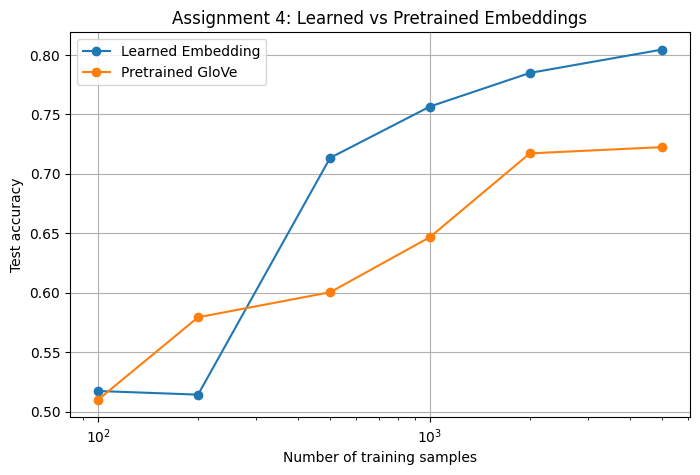

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(results_sizes["train_samples"], results_sizes["learned_embedding_acc"], marker="o", label="Learned Embedding")
plt.plot(results_sizes["train_samples"], results_sizes["pretrained_glove_acc"], marker="o", label="Pretrained GloVe")
plt.xscale("log")
plt.xlabel("Number of training samples")
plt.ylabel("Test accuracy")
plt.title("Assignment 4: Learned vs Pretrained Embeddings")
plt.legend()
plt.grid(True)
plt.show()